<a href="https://colab.research.google.com/github/sankajithdjinasena/Data_Visualization_Practical/blob/main/Data_Visualization_2026_06_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Expressiveness: The ability to clearly and effectively convey ideas, emotions, meanings, or information.

Example: "Python is known for its expressiveness because code can often be written in a simple and readable way."

## Effectiveness: The degree to which something successfully achieves its intended purpose or produces the desired result.

Example: "The effectiveness of the algorithm was measured by its accuracy and speed."

---
- Simple Difference
  - Expressiveness = How well something can express or represent ideas.
  - Effectiveness = How well something works or achieves its goal.

In [3]:
data = {
    "drink" :["Latte","Espresso","Tea"],
    "total_sales":[500,200,300],
    "wait_time_mins":[5,2,3]
    }

In [4]:
df = pd.DataFrame(data)

/tmp/ipykernel_4618/3448539090.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


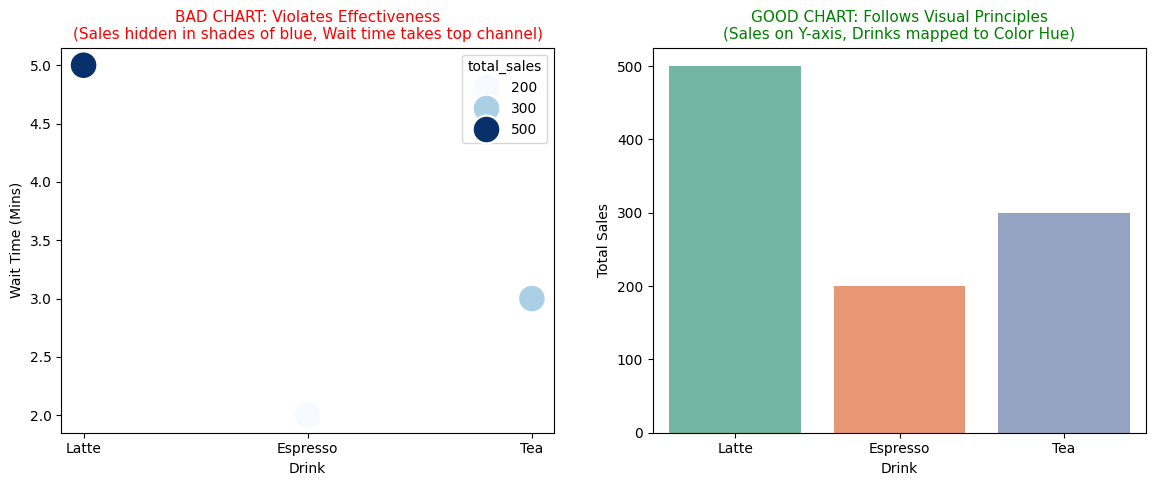

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

sns.scatterplot(
    ax = axes[0],
    data = df,
    x='drink',
    y='wait_time_mins',
    hue="total_sales",
    palette="Blues",
    s=400
)

axes[0].set_title("BAD CHART: Violates Effectiveness\n(Sales hidden in shades of blue, Wait time takes top channel)",fontsize=11, color='red')
axes[0].set_ylabel("Wait Time (Mins)")
axes[0].set_xlabel("Drink")

sns.barplot(
    ax = axes[1],
    data = df,
    x='drink',
    y='total_sales',
    palette="Set2",
    legend=False
)

axes[1].set_title("GOOD CHART: Follows Visual Principles\n(Sales on Y-axis, Drinks mapped to Color Hue)", fontsize=11, color="green")
axes[1].set_ylabel("Total Sales")
axes[1].set_xlabel("Drink")

plt.show()


In [11]:
df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [12]:
df["cut"].value_counts()

,count
cut,
Ideal,21551
Premium,13791
Very Good,12082
Good,4906
Fair,1610


## Task 1

/tmp/ipykernel_4618/3410785896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4618/3410785896.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


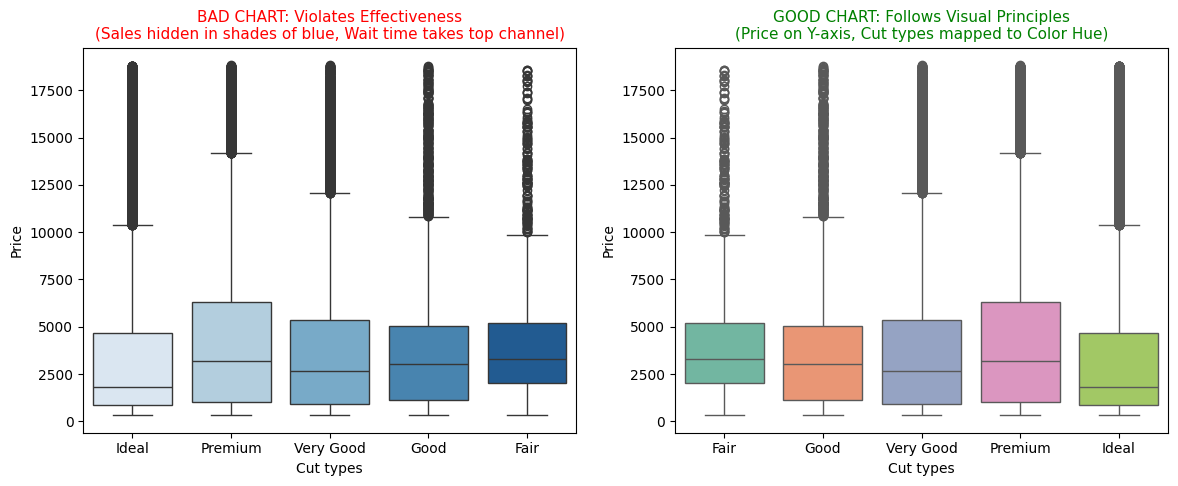

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

sns.boxplot(
    ax = axes[0],
    data = df,
    x='cut',
    y='price',
    palette="Blues",
)

axes[0].set_title("BAD CHART: Violates Effectiveness\n(Sales hidden in shades of blue, Wait time takes top channel)",fontsize=11, color='red')
axes[0].set_ylabel("Price")
axes[0].set_xlabel("Cut types")

sns.boxplot(
    ax = axes[1],
    data = df,
    x='cut',
    y='price',
    palette="Set2",
    order = ["Fair","Good","Very Good","Premium","Ideal"]
)

axes[1].set_title("GOOD CHART: Follows Visual Principles\n(Price on Y-axis, Cut types mapped to Color Hue)", fontsize=11, color="green")
axes[1].set_ylabel("Price")
axes[1].set_xlabel("Cut types")
plt.show()

## Task 2

In [23]:
avg_price_per_cut = df.groupby("cut")["price"].mean()
avg_price_per_cut

/tmp/ipykernel_4618/1782748902.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_per_cut = df.groupby("cut")["price"].mean()


,price
cut,
Ideal,3457.541970
Premium,4584.257704
Very Good,3981.759891
Good,3928.864452
Fair,4358.757764


Text(0.5, 1.0, 'Average Diamond Price by Cut Quality')

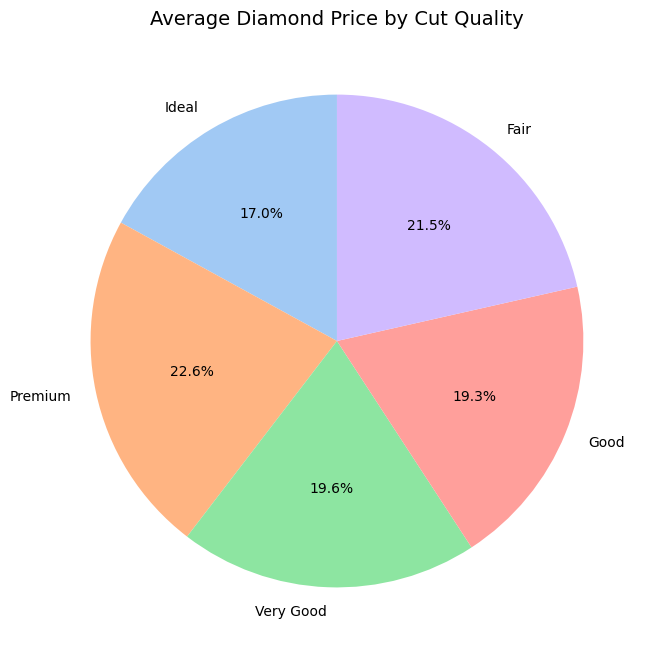

In [31]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(avg_price_per_cut.values, labels=avg_price_per_cut.index, autopct='%1.1f%%',
       startangle=90, colors=sns.color_palette('pastel'))
ax.set_title('Average Diamond Price by Cut Quality', fontsize=14)

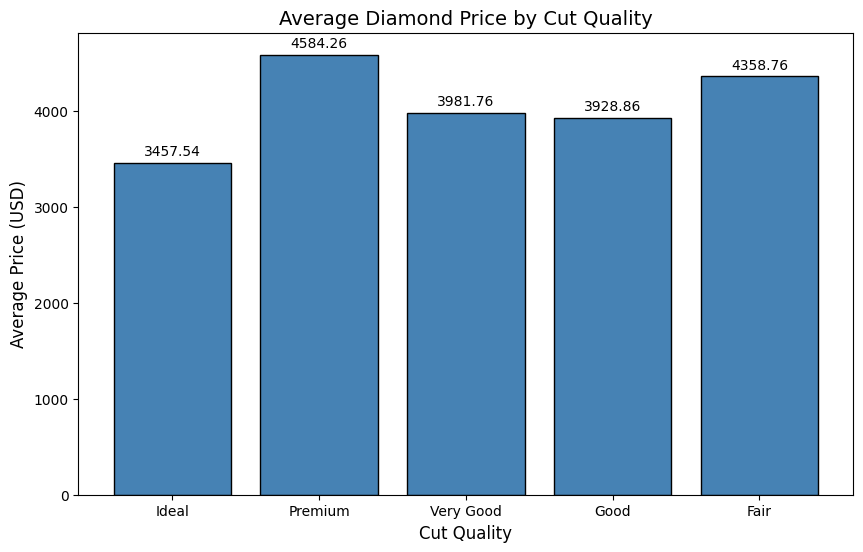

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(avg_price_per_cut.index, avg_price_per_cut.values, color='steelblue', edgecolor='black')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_title('Average Diamond Price by Cut Quality', fontsize=14)
ax.set_xlabel('Cut Quality', fontsize=12)
ax.set_ylabel('Average Price (USD)', fontsize=12)
plt.show()

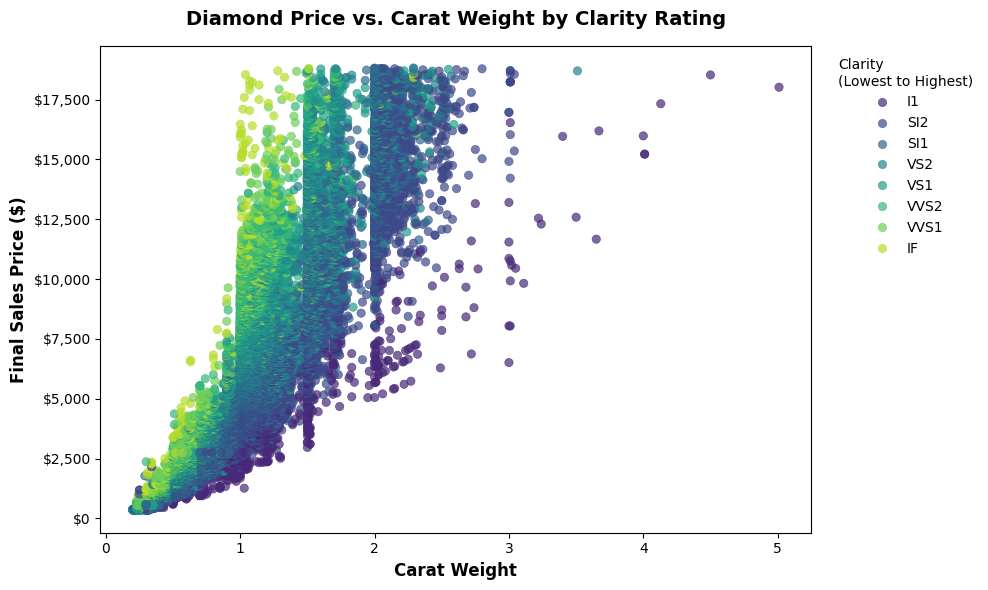

In [33]:
df = sns.load_dataset('diamonds')

clarity_ranking = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='carat',
    y='price',
    hue='clarity',
    hue_order=clarity_ranking,
    palette='viridis',
    alpha=0.7,
    edgecolor=None,
    ax=ax
)

ax.set_title("Diamond Price vs. Carat Weight by Clarity Rating", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Carat Weight", fontsize=12, fontweight='bold')
ax.set_ylabel("Final Sales Price ($)", fontsize=12, fontweight='bold')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))

ax.legend(title="Clarity\n(Lowest to Highest)", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()
